## Community Detection

In this section, we explore how Community Detection algorithms can identify clusters even when "noise" (inter-group connections) exists. We use an Adjacency Matrix to represent the network, where $A_{ij}$

​
  denotes the strength of the connection between individuals i and j.

  

1. Data Preparation with Multiple Bridges

I will make a 10-node network with two primary groups. To make it a little more challenging for the algorithm, I'll also add two weaker bridges between the groups.

In [11]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

class LabelPropagation:
    def __init__(self, max_iter=100, random_state=None):
        self.max_iter = max_iter
        self.random_state = random_state
        self.labels_ = None
        self.n_iter_ = 0
        self.n_communities_ = 0

    def fit(self, A):
        if self.random_state:
            np.random.seed(self.random_state)

        n = A.shape[0]
        # Start everyone with a unique label
        self.labels_ = np.arange(n)

        for i in range(self.max_iter):
            old_labels = self.labels_.copy()
            # Randomize node order to prevent bias
            nodes = np.random.permutation(n)

            for node in nodes:
                neighbors = np.where(A[node] > 0)[0]
                if len(neighbors) > 0:
                    # Find which label has the most "weight" in the neighborhood
                    neighbor_labels = self.labels_[neighbors]
                    weights = A[node][neighbors]

                    unique_labels = np.unique(neighbor_labels)
                    label_scores = {l: 0 for l in unique_labels}

                    for l, w in zip(neighbor_labels, weights):
                        label_scores[l] += w

                    # Update to the "heaviest" label
                    self.labels_[node] = max(label_scores, key=label_scores.get)

            self.n_iter_ = i + 1
            if np.array_equal(old_labels, self.labels_):
                break

        self.n_communities_ = len(np.unique(self.labels_))
# Create the Graph Data (Adjacency Matrix)
N = 10
A = np.zeros((N, N))

# Community 1 (Nodes 0-4): Strong internal links (weight 5)
A[0:5, 0:5] = 5
np.fill_diagonal(A[0:5, 0:5], 0)

# Community 2 (Nodes 5-9): Strong internal links (weight 5)
A[5:10, 5:10] = 5
np.fill_diagonal(A[5:10, 5:10], 0)

# Single weak inter-community link (Node 4 connects to Node 5)
A[4, 5] = 1
A[5, 4] = 1

A = np.maximum(A, A.T)
print(f"Adjacency Matrix (10x10):\n{A}")

Adjacency Matrix (10x10):
[[0. 5. 5. 5. 5. 0. 0. 0. 0. 0.]
 [5. 0. 5. 5. 5. 0. 0. 0. 0. 0.]
 [5. 5. 0. 5. 5. 0. 0. 0. 0. 0.]
 [5. 5. 5. 0. 5. 0. 0. 0. 0. 0.]
 [5. 5. 5. 5. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 5. 5. 5. 5.]
 [0. 0. 0. 0. 0. 5. 0. 5. 5. 5.]
 [0. 0. 0. 0. 0. 5. 5. 0. 5. 5.]
 [0. 0. 0. 0. 0. 5. 5. 5. 0. 5.]
 [0. 0. 0. 0. 0. 5. 5. 5. 5. 0.]]


2. Model Implementation

The Label Propagation algorithm works by having nodes adopt the labels of their neighbors based on connection weights. Even with the extra bridges, the higher internal weights (5 v 1) should allow the communities to remain distinct.

In [12]:
# 2. Initialize and Run the Model
lpa = LabelPropagation(max_iter=50, random_state=67)

print("\nBeginning Label Propagation...")
lpa.fit(A)
print("Propagation Complete.")
print(f"Iterations run: {lpa.n_iter_}")
print(f"Number of communities found: {lpa.n_communities_}")


Beginning Label Propagation...
Propagation Complete.
Iterations run: 2
Number of communities found: 2


3. Visualization and Analysis

Visualizing the network helps confirm that they did not cause the two groups to merge into one large, messy cluster.

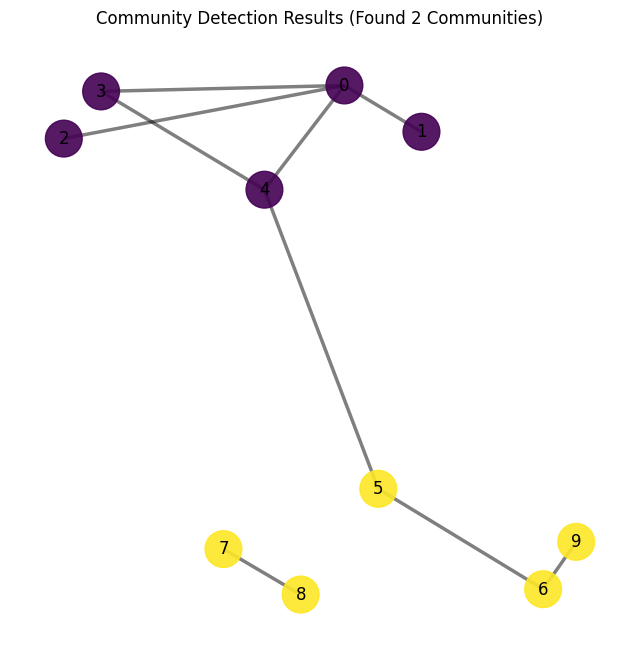


--- Final Community Assignment ---
Node 0: Community 1
Node 1: Community 1
Node 2: Community 1
Node 3: Community 1
Node 4: Community 1
Node 5: Community 5
Node 6: Community 5
Node 7: Community 5
Node 8: Community 5
Node 9: Community 5


In [13]:
# 3. Results and Visualization
community_labels = lpa.labels_
unique_labels = np.unique(community_labels)

# Clean way to handle colors in modern Matplotlib
cmap = plt.colormaps.get_cmap('viridis')
norm = plt.Normalize(vmin=unique_labels.min(), vmax=unique_labels.max())
node_colors = [cmap(norm(label)) for label in community_labels]

G = nx.from_numpy_array(A)

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, seed=67)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=A[np.triu_indices(N, k=1)] * 0.5, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_color='black')

plt.title(f"Community Detection Results (Found {lpa.n_communities_} Communities)")
plt.axis('off')
plt.show()

print("\n--- Final Community Assignment ---")
for node_id, label in enumerate(community_labels):
    print(f"Node {node_id}: Community {label}")